In [577]:
# Export Libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


In [578]:
# Load the data

df = pd.read_csv('temperature_sensor_data.csv')

df.head(10)


,ADC_Value,Temperature_C
0,320,20.1
1,335,21.4
2,350,22.0
3,365,22.8
4,380,23.9
5,395,24.6
6,410,25.7
7,425,26.4
8,440,27.3
9,455,28.2


In [579]:
# Convert pd dataframe to numpy arrays

X = df['ADC_Value'] # (n)
y = df['Temperature_C'] # (n)

X_array = X.to_numpy()
y_array = y.to_numpy()

In [580]:
# Predict 

def predict(X,w,b):
    return w*X + b

In [581]:
# Cost Computation

def compute_cost(X_array,y_array, w,b) :
    y_pred = w*X_array + b
    cost = np.mean((y_array - y_pred) ** 2)
    return cost


In [582]:
# Gradient Computation

def compute_gradients(X_array, y_array, w, b) :
    n = len(y_array)
    y_pred = w*X_array + b

    dw = (2/n) * np.sum((y_pred - y_array) * X)
    db = (2/n) * np.sum((y_pred - y_array))

    return dw, db

In [583]:
# Update Parameters

def gradient_descent_step(X_array, y_array, w, b, lr) :
    dw, db = compute_gradients(X_array, y_array, w,b)

    w = w - (lr * dw)
    b = b - (lr * db)

    return w,b

In [584]:
# Training Loop

w = 0
b = 0
lr = 1e-7

for i in range(5000) :
    w,b = gradient_descent_step(X_array, y_array, w, b, lr)

    if(i % 100) == 0 :
        cost = compute_cost(X_array, y_array, w, b)
        print(f"Iteration Number : {i}, Cost : {cost}")

    
print(f"Final Weight : {w}, Final Bias : {b}")

y_pred = predict(X_array, w, b)

Iteration Number : 0, Cost : 1005.9414013363912
Iteration Number : 100, Cost : 0.2026592473903417
Iteration Number : 200, Cost : 0.1993362289956181
Iteration Number : 300, Cost : 0.19933580319472968
Iteration Number : 400, Cost : 0.19933538837142098
Iteration Number : 500, Cost : 0.19933497354906363
Iteration Number : 600, Cost : 0.19933455872762046
Iteration Number : 700, Cost : 0.19933414390709198
Iteration Number : 800, Cost : 0.199333729087478
Iteration Number : 900, Cost : 0.1993333142687792
Iteration Number : 1000, Cost : 0.19933289945099658
Iteration Number : 1100, Cost : 0.19933248463412498
Iteration Number : 1200, Cost : 0.19933206981817128
Iteration Number : 1300, Cost : 0.19933165500313121
Iteration Number : 1400, Cost : 0.19933124018900525
Iteration Number : 1500, Cost : 0.19933082537579574
Iteration Number : 1600, Cost : 0.1993304105635012
Iteration Number : 1700, Cost : 0.19932999575211902
Iteration Number : 1800, Cost : 0.19932958094165407
Iteration Number : 1900, Cost :

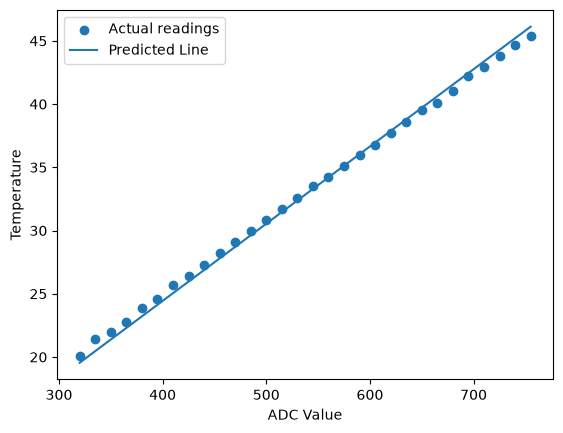

In [585]:
# Plot Actual vs Predicted

plt.scatter(df['ADC_Value'], df['Temperature_C'], label = 'Actual readings')

plt.plot(X_array, y_pred, label = 'Predicted Line')

plt.xlabel('ADC Value')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [586]:
mae = np.mean(abs(y_pred - y_array))
mse = np.mean((y_pred - y_array) ** 2)
rmse = mse ** 0.5

ss_res = np.sum(((y_array - y_pred)) ** 2)
ss_tot = np.sum(((y_array - np.mean(y_array))) ** 2)

r2 = 1 - (ss_res / ss_tot)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"R2 Score : {r2}")



MAE : 0.38949750446796993
MSE : 0.19931631163749483
RMSE : 0.4464485543010469
R2 Score : 0.9964662936494082


In [587]:
# Predict
adc_vector = np.array([400,525,670])
p_vector = predict(adc_vector, w, b)

for adc, temp in zip(adc_vector, p_vector):
    print(f"The temperature at ADC Value {adc}: {temp}")



The temperature at ADC Value 400: 24.43528030499083
The temperature at ADC Value 525: 32.07124001909216
The temperature at ADC Value 670: 40.9289532874497
